0.6428571428571429
[[8 5]
 [0 1]]
              precision    recall  f1-score   support

       False       1.00      0.62      0.76        13
        True       0.17      1.00      0.29         1

    accuracy                           0.64        14
   macro avg       0.58      0.81      0.52        14
weighted avg       0.94      0.64      0.73        14

0.5


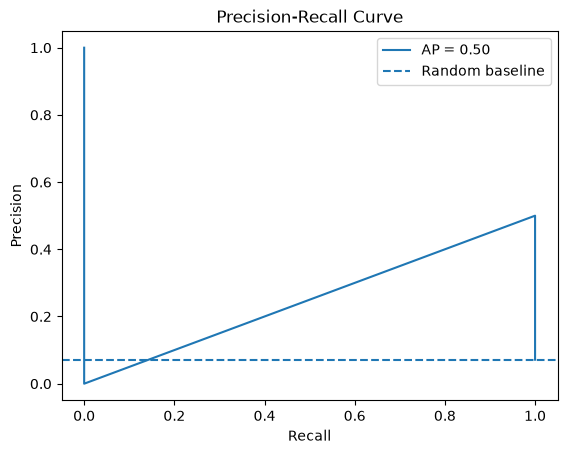

[0.07142857 0.07692308 0.08333333 0.09090909 0.1        0.11111111
 0.125      0.14285714 0.16666667 0.2        0.25       0.33333333
 0.5        0.         1.        ]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0.]
True


In [6]:
# ====================================
# Import
# ====================================
from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

import joblib

def evaluate_pr(model, X_test, y_test):

    prob = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(
        y_test,
        prob
    )

    ap = average_precision_score(
        y_test,
        prob
    )

    print(ap)

    return precision, recall, ap

def plot_pr(baseline, precision, recall, ap):

    plt.plot(
        recall,
        precision,
        label=f"AP = {ap:.2f}"
    )

    plt.axhline(
        y = baseline,
        linestyle="--",
        label="Random baseline"
    )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(
        "Precision-Recall Curve"
    )

    plt.legend()
    plt.show()


# ====================================
# Load
# ====================================

BASE_DIR = Path.cwd()

ini_file = BASE_DIR / "data" / "employees.csv"

df = pd.read_csv(ini_file)

# ====================================
# Data Cleaning
# ====================================

df["PerformanceScore"] = df["PerformanceScore"].fillna(
    df["PerformanceScore"].mode()[0]
)
df["Education"] = df["Education"].fillna(
    df["Education"].mode()[0]
)

# ====================================
# Creating unbalanced data
# ====================================

df["HighSalary"] = (
    df["Salary"] >= df["Salary"].median()
)

df_false = df[
    df["HighSalary"] == False
]

df_true = df[
    df["HighSalary"] == True
]

df_true = df_true.sample(
    n=10,
    random_state=42
)

df = pd.concat(
    [
        df_false,
        df_true
    ]
)

# ====================================
# Feature Selection
# ====================================

X = df[[
    "PerformanceScore",
    "Education",
    "Department",
    "Experience"
]].copy()


# ====================================
# Feature Engineering
# ====================================

X["ExperienceScore"] = (
    X["Experience"] * X["PerformanceScore"]
)

# ====================================
# Target
# ====================================

y = df["HighSalary"]

# ====================================
# Train/Test Split
# ====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ====================================
# Feature split
# ====================================

numeric_features = [
    "PerformanceScore",
    "Experience",
    "ExperienceScore"
]

categorical_features = [
    "Education",
    "Department"
]

# ====================================
# ColumnTransformer
# ====================================

preprocessor = ColumnTransformer([
    (
        "numeric",
        StandardScaler(),
        numeric_features
    ),
    (
        "categorical",
        OneHotEncoder(drop="first"),
        categorical_features
    )
])

# ====================================
# Pipeline and pipeline usage
# ====================================

pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced"
        )
    )
])

pipeline.fit(X_train, y_train)

model_path = BASE_DIR / "models" / "logistic_regression.pkl"

joblib.dump(
    pipeline,
    model_path
)

pred = pipeline.predict(
    X_test
)

loaded_model = joblib.load(
    model_path
)

pred_loaded = loaded_model.predict(
    X_test
)


# ====================================
# Model Evaluation
# ====================================

print(
    accuracy_score(
        y_test,
        pred
    )
)

print(
    confusion_matrix(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

#print(pipeline)

# PR Curve

precision, recall, ap = evaluate_pr(
    pipeline,
    X_test,
    y_test
)

baseline = y_test.mean()

plot_pr(
    baseline,
    precision,
    recall,
    ap
)

print(precision)
print(recall)

loaded_pred = loaded_model.predict(X_test)

print(
    (pred == loaded_pred).all()
)